# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

## <font color='green'>Preparação</font>

In [32]:
!pip install pandas scikit-learn ucimlrepo

In [53]:
import numpy as np
from ucimlrepo import fetch_ucirepo
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [34]:
rows_original = X.shape[0]
X.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [35]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [36]:
X.dropna(inplace=True)

/tmp/ipykernel_7777/490656300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


In [37]:
y = y.iloc[X.index]
y.shape

(392, 1)

In [38]:
print(f"Foram removidos {rows_original-X.shape[0]} linhas")

Foram removidos 6 linhas


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

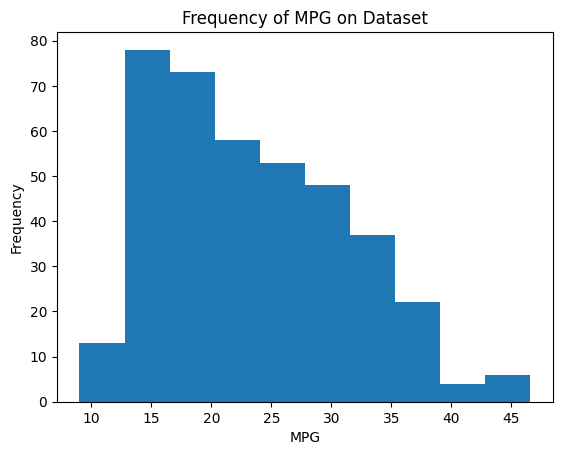

In [39]:
plt.hist(y)
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.title("Frequency of MPG on Dataset")
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A maioria dos carros gastam um litro de gasolina pra percorrer apenas 15 milhas

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

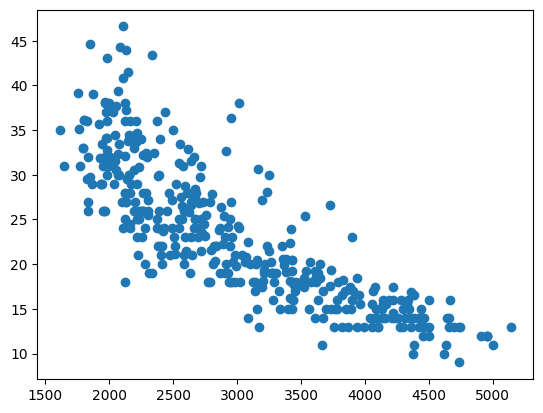

In [42]:
plt.scatter(X['weight'], y)

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X['weight'], y, test_size=0.2, random_state=42)

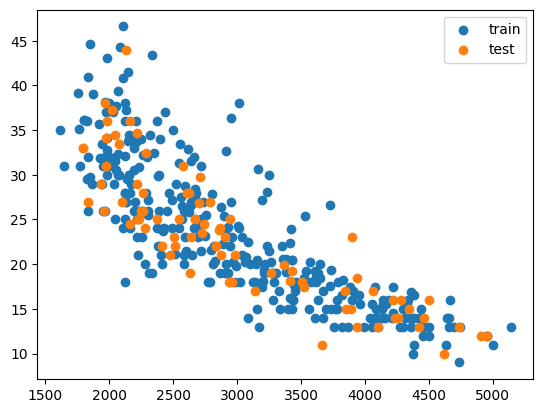

In [52]:
plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.legend()

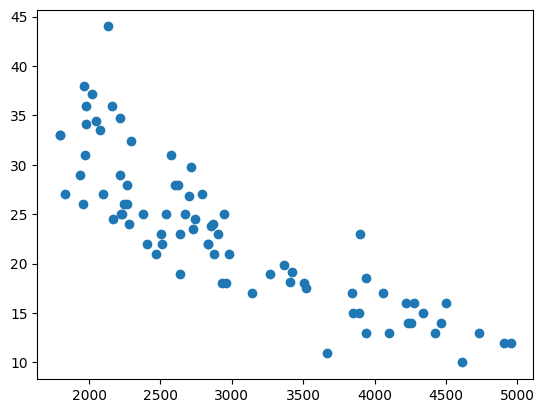

In [47]:
plt.scatter(X_test, y_test)

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [56]:
class LinearRegression:
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)
        self.__correlation_coefficient = self.__correlacao()
        self.__inclination = self.__inclinacao()
        self.__intercept = self.__interceptacao()

    def __correlacao(self):
        covariacao = np.cov(self.x, self.y, bias=True)[0][1]
        variancia_x = np.var(self.x)
        variancia_y = np.var(self.y)

        return covariacao/np.sqrt(variancia_x*variancia_y)

    def __inclinacao(self):
        stdx = np.std(self.x)
        stdy = np.std(self.y)

        return self.__correlation_coefficient * (stdy/stdx)

    def __interceptacao(self):
        mediax = np.mean(self.x)
        mediay = np.mean(self.y)

        return  mediay - mediax*self.__inclination

    def previsao(self, valor):

        return self.__intercept + (self.__inclination * valor)

In [58]:
ln = LinearRegression(X_train, y_train)
y_pred = ln.previsao(X_test)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 318 and the array at index 1 has size 1

### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>